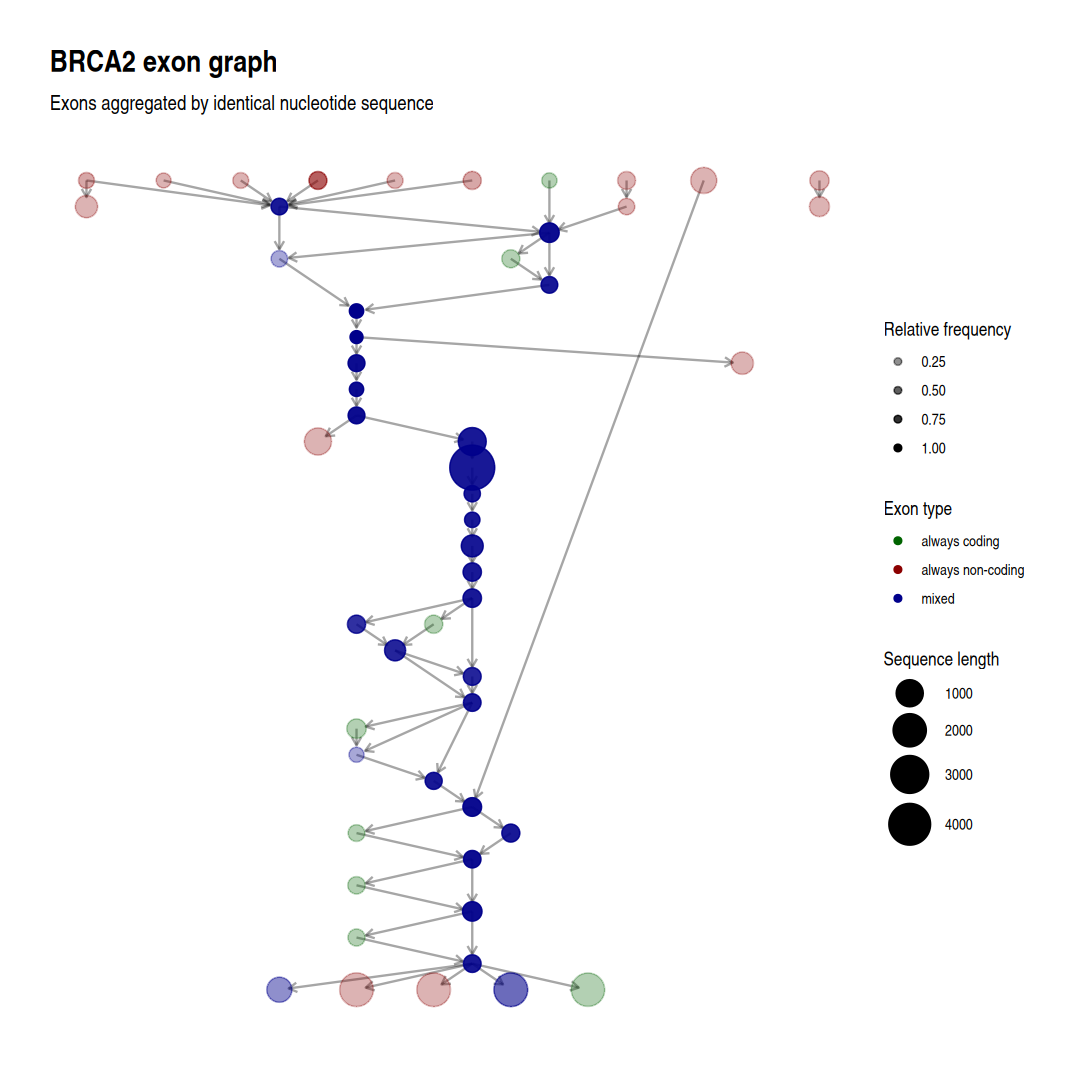

In [12]:
#!/usr/bin/env Rscript

# Simple exon graph from fetch_isoforms.py output.
# Exons are aggregated only by identical nucleotide sequence.
# Node size = nucleotide sequence length.
# Node alpha = relative frequency across transcript-exon rows.
# Color:
#   dark green = always coding
#   dark red   = always non-coding
#   dark blue  = mixed coding/non-coding

INPUT_FILE <- "data/human_gene_exons/ENSG00000139618_exons.tsv"
title = "BRCA2 exon graph"

library(tidyr)
library(dplyr)
library(igraph)
library(ggraph)

df <- readr::read_tsv(INPUT_FILE, show_col_types = FALSE) %>%
  mutate(
    is_coding = as.logical(is_coding),
    exon_sequence = replace_na(exon_sequence, ""),
    exon_key = exon_sequence
  )

nodes <- df %>%
  group_by(exon_key) %>%
  summarise(
    sequence_length = nchar(first(exon_sequence)),
    n_rows = n(),
    always_coding = all(is_coding),
    always_noncoding = all(!is_coding),
    exon_numbers = paste(sort(unique(exon_number)), collapse = ","),
    .groups = "drop"
  ) %>%
  mutate(
    name = exon_key,
    relative_frequency = n_rows / max(n_rows),
    exon_type = case_when(
      always_coding ~ "always coding",
      always_noncoding ~ "always non-coding",
      TRUE ~ "mixed"
    ),
    label = paste0("exon ", exon_numbers)
  )

edges <- df %>%
  arrange(transcript_id, exon_number) %>%
  group_by(transcript_id) %>%
  mutate(
    from = exon_key,
    to = lead(exon_key)
  ) %>%
  ungroup() %>%
  filter(!is.na(to), from != to) %>%
  count(from, to, name = "weight")

graph <- graph_from_data_frame(edges, vertices = nodes, directed = TRUE)

splicing_graph <- ggraph(graph, layout = "sugiyama") +
  geom_edge_link(
    arrow = arrow(length = unit(2, "mm")),
    end_cap = circle(2, "mm"),
    alpha = 0.35
  ) +
  geom_node_point(
    aes(
      size = sequence_length,
      alpha = relative_frequency,
      color = exon_type
    )
  ) +
#  geom_node_text(
#    aes(label = label),
#    repel = TRUE,
#    size = 3
#  ) +
  scale_color_manual(
    values = c(
      "always coding" = "darkgreen",
      "always non-coding" = "darkred",
      "mixed" = "darkblue"
    )
  ) +
  scale_size_continuous(range = c(3, 12)) +
  scale_alpha_continuous(range = c(0.3, 1)) +
  labs(
    title = title,
    subtitle = "Exons aggregated by identical nucleotide sequence",
    color = "Exon type",
    size = "Sequence length",
    alpha = "Relative frequency"
  ) +
  theme_graph()

options(repr.plot.height=9, repr.plot.width=9)
splicing_graph

In [16]:
outdir = "plots"
dir.create(showWarnings=FALSE, outdir)
ggsave(splicing_graph, file=file.path(outdir, "BRCA2 structure.png"), width=9, height=9)